# Lab Week 2: Plotting Exercises

In this lab, you need to solve some exercises with matplotlib, a python library for plotting.

<div style="border-bottom: 3px solid black; margin-bottom:5px"></div>
<div style="border-bottom: 3px solid black;"></div>

## 1. Plotting exercises
First, in the code cell below, write code to import the _pyplot_ module from the Matplotlib package in the standard way, then run the code cell.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

If you imported the _pyplot_ module from Matplotlib correctly you should be able to run the code cell below without error.

In [ ]:
assert 'matplotlib' not in globals(), "You didn't need to import matplotlib itself, just the pyplot submodule."
assert 'pyplot' not in globals(), "You didn't import pyplot in the standard way. Do Kernel->Restart and then try again."
assert 'plt' in globals(), "You didn't import pyplot in the standard way. Do Kernel->Restart and then try again."
print("Ready!")

Ready!


**Run the code below** to download the images used for this lab assignment.

In [ ]:
%%capture
!pip install gdown==v4.6.3
!gdown 1Tbe__HuYe3AAd3ypwvFdYgfc0cEZA7Pf
!gdown 17V68w37OLszWRTehRt1vQS5Hybv58NmR

<div style="border-bottom: 3px solid black;"></div>

### Exercise 1.1 &ndash; Plot a function

**Plot these functions** over the interval $x \in [-5, 5]$:

1. The [sigmoid](https://en.wikipedia.org/wiki/Sigmoid_function) function $\sigma(x) = \frac{1}{1+e^{-x}}$
2. The (leaky) [rectifier](https://en.wikipedia.org/wiki/Rectifier_(neural_networks)) function $f(x) = \max(0, x) + \text{negative_slope}\times \min(0, x)$

Requirements:
* Use Numpy ndarrays and Numpy functions for your solution, _not_ Python lists.
* Plot both curves in the same plot
* Use the **plt.[ylim](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.ylim.html)** function to set the y axis range to $[-0.5,3.1]$.
* Use the **plt.[grid](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.grid.html)** function to show a grid.
* Use the **plt.[xlabel](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.xlabel.html)** function to set the x-axis label.
* Use the **plt.[legend](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.legend.html)** function to add a legend.
* Use the **plt.[title](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.title.html)** function to add a title.
* Take negative_slope as 0.05.
You should be able to reproduce the plot below:

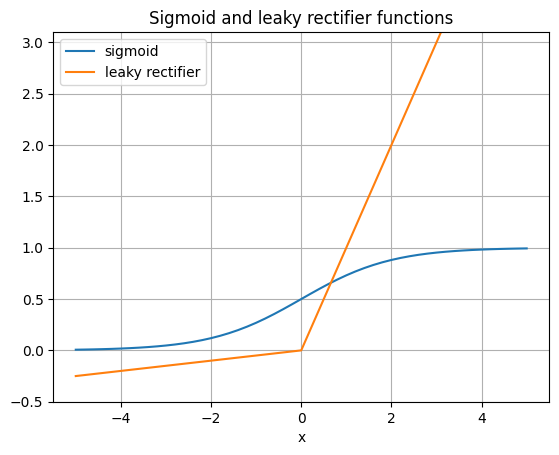

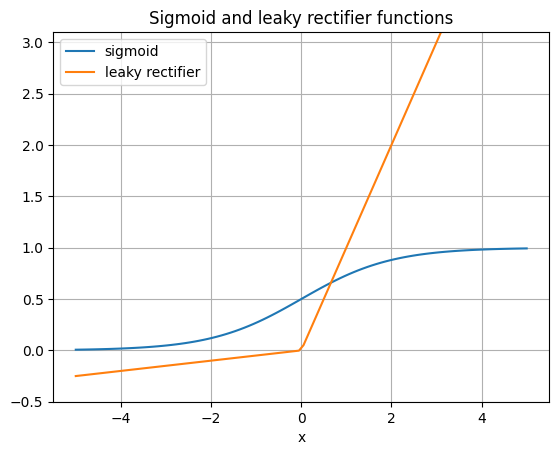

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the sigmoid function: σ(x) = 1 / (1 + e^-x)
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# 2. Define the leaky rectifier function: f(x) = max(0, x) + slope * min(0, x)
def leaky_relu(x, negative_slope=0.05):
    return np.maximum(0, x) + negative_slope * np.minimum(0, x)

# Generate the interval x in [-5, 5] using a NumPy ndarray
x = np.linspace(-5, 5, 100)

# Plotting
plt.plot(x, sigmoid(x), label='sigmoid')
plt.plot(x, leaky_relu(x), label='leaky rectifier')

# Formatting requirements
plt.ylim([-0.5, 3.1])
plt.grid(True)
plt.xlabel('x')
plt.title('Sigmoid and leaky rectifier functions')
plt.legend()

plt.show()

<div style="border-bottom: 3px solid black;"></div>

### Exercise 1.2 &ndash; Plot accuracy of finite differences

In the previous lab, we defined a function that approximates the derivative of f at any point.

**Run** the code below* to resume this function.

In [ ]:
def approx_derivative_of(f, epsilon=1e-5):
    """Returns a new function that approximates the derivative of f at any point.

    Arguments:
    f       -- the function f(x) whose derivative we wish to approximate
    epsilon -- the step size to use for central differencing (default 1e-5)
    """
    return lambda x: (f(x + epsilon) - f(x - epsilon)) / (2*epsilon)

**Plot the accuracy** of the central difference approximation for different values of the step size $\epsilon$. Your plot should show that the finite difference approximation breaks down for values of $\epsilon$ that are too large or too small.

**Run the code cell below** to define functions for $f(x) = x^3$ and its exact first derivative $f'(x) = 3x^2$.

In [ ]:
def f(x):
    return x**3

def df_exact(x):
    return 3 * x**2

First, plot the `f` and `f_exact` functions over range $x \in [-1.2, 1.2]$, including title and legend as shown below:


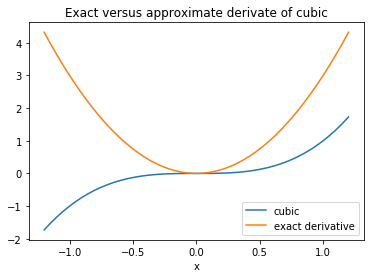

Second, once you've got the above plot, use the `approx_derivative_of(f, epsilon)` function to add three new series to your plot, corresponding to $\epsilon=1$, $\epsilon=10^{-5}$, and $\epsilon=10^{-15}$. Your new plot should look like this:

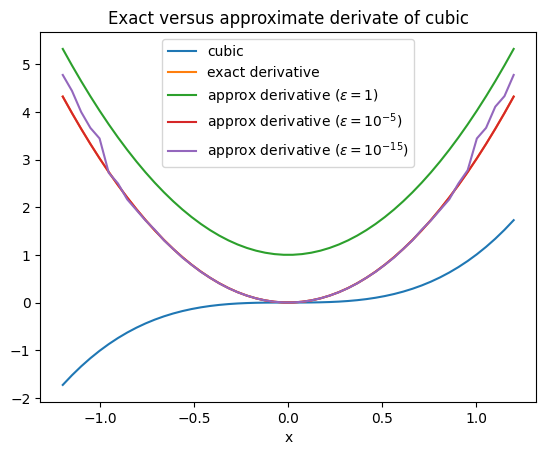

Make greek symbols like $\epsilon$ in a label or a title by using the dollar sign (\$) and superscript (^), such as `"Argument $\beta$ has value $10^{3}$"` would render in the plot as <span style="border: 1px solid #ddd; padding:3px;">Argument $\beta$ has value $10^3$</span>

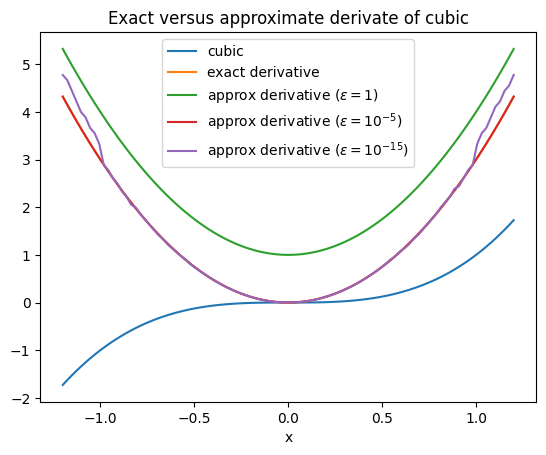

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Range for plotting
x = np.linspace(-1.2, 1.2, 100)

# Plotting the base functions
plt.plot(x, f(x), label='cubic')
plt.plot(x, df_exact(x), label='exact derivative')

for eps in [1, 1e-5, 1e-15]:
    approx_func = approx_derivative_of(f, epsilon=eps)
    label_text = rf'approx derivative ($\epsilon = 10^{{{int(np.log10(eps))}}}$)' if eps < 1 else r'approx derivative ($\epsilon = 1$)'
    plt.plot(x, approx_func(x), label=label_text)

# Formatting the plot
plt.title('Exact versus approximate derivate of cubic')
plt.xlabel('x')
plt.legend()
plt.show()

<div style="border-bottom: 3px solid black;"></div>

### Exercise 1.3 &ndash; Plot a stack of images

**Stack two images and plot them.** Follow these steps:

1. The lab comes with a file called [mnist-digit-2.png](mnist-digit-2.png). It contains a 32x32 RBG image (red, green, blue colour channels).
2. Use the **plt.[imread](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.imread.html)** function the load the file. Notice that the result of _imread_ is an _ndarray_ object of dtype _np.uint8_ and shape (32,32,3).
3. Use the **plt.[imshow](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.imshow.html)** function to plot the image. The plot should look like this:

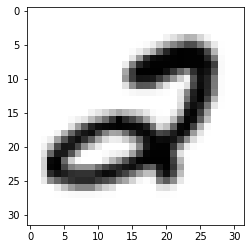
4. The lab also comes with a file called [mnist-digit-3.png](mnist-digit-3.png). It contains another 32x32 RGB image.
5. Flip the [mnist-digit-3.png](mnist-digit-3.png) image horizontally using **np.[flip](https://numpy.org/doc/2.1/reference/generated/numpy.flip.html)**
5. Use the **np.[hstack](https://www.numpy.org/devdocs/reference/generated/numpy.hstack.html)** function to create a new image where the digits are side-by-side.
5. Plot new composite image. It should look like this:

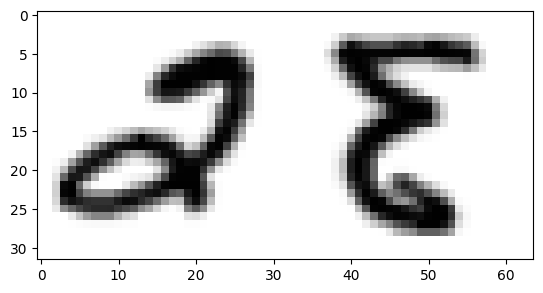

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


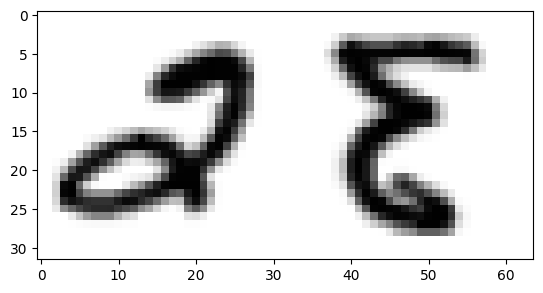

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1 & 2. Load the images as numpy arrays
img2 = plt.imread('mnist-digit-2.png')
img3 = plt.imread('mnist-digit-3.png')

# 4. Flip the '3' horizontally (axis=1 refers to the width/columns)
img3_flipped = np.flip(img3, axis=1)

# 5. Stack them side-by-side (horizontally)
composite_image = np.hstack((img2, img3_flipped))

# 6. Plot the final result
plt.imshow(composite_image)
plt.show()

<div style="border-bottom: 3px solid black;"></div>

### Exercise 1.4 &ndash; Plot a normal distribution

The probability density function (PDF) of a normal distribution is defined as follows:
$$
f(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left( -\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^{\!2}\,\right),
$$
where $\mu \in \mathbb{R}$ represents the mean and $\sigma \in \mathbb{R}_+$ the standard deviation.

**Plot a normal distribution.** Follow these steps:
* Implement function `normal_pdf` and plot the PDF.
* Use the **plt.[axvline](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.axvline.html)** to plot the vertical line at `x=mu`.
* Use the **plt.[fill_between](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.fill_between.html)** multiple times to fill the areas according to the [68-95-99.7 rule](https://en.wikipedia.org/wiki/68%E2%80%9395%E2%80%9399.7_rule). <br> Use arguments `where` and `alpha` to select the regions to fill and the opacity, respectively.
* Use the **plt.[scatter](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.scatter.html)** to plot the inflection point. Use arguments `zorder`, `s` and `edgecolors` <br> to set the drawing order, the marker size and the edge color, respectively.
* Use the **plt.[annotate](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.annotate.html)** to annotate the inflection point.
* Use the **plt.[xticks](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.xticks.html)** to set the tick locations and labels.
* Set proper x and y limits, add title and axis labels.

Your plot should look similar to the following:

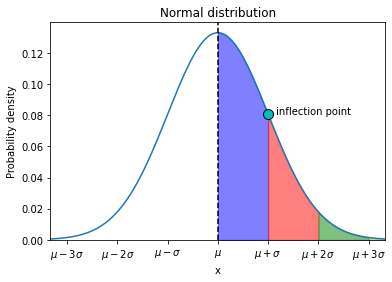

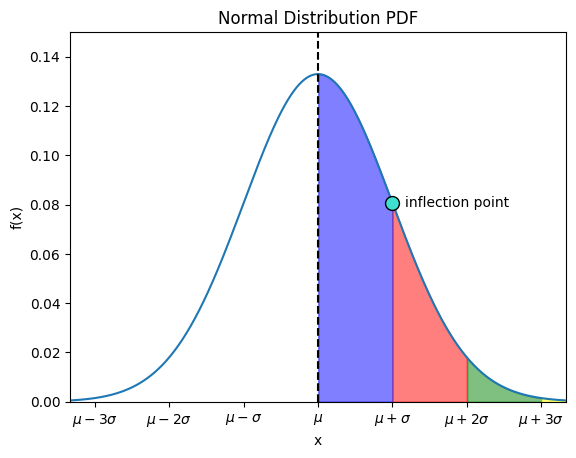

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Implement the normal_pdf function
def normal_pdf(x, mu, sigma):
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma)**2)

# Parameters provided in the notebook
x = np.linspace(-10., 10., num=1000)
mu = 0.
sigma = 3.
pdf = normal_pdf(x, mu, sigma)
inflection_point_x = mu + sigma
inflection_point_y = normal_pdf(inflection_point_x, mu, sigma)

# 2. Plotting the PDF
plt.plot(x, pdf)

# 3. Add vertical line at the mean (mu)
plt.axvline(x=mu, color='black', linestyle='--')

# 4. Fill areas according to the 68-95-99.7 rule
# Region within 1 sigma (68%)
plt.fill_between(x, pdf, where=(x >= mu) & (x <= mu + sigma), color='blue', alpha=0.5)
# Region between 1 and 2 sigmas (part of 95%)
plt.fill_between(x, pdf, where=(x >= mu + sigma) & (x <= mu + 2*sigma), color='red', alpha=0.5)
# Region between 2 and 3 sigmas (part of 99.7%)
plt.fill_between(x, pdf, where=(x >= mu + 2*sigma) & (x <= mu + 3*sigma), color='green', alpha=0.5)
# Region beyond 3 sigmas
plt.fill_between(x, pdf, where=(x >= mu + 3*sigma), color='yellow', alpha=0.5)

# 5. Scatter and annotate the inflection point
plt.scatter(inflection_point_x, inflection_point_y, color='turquoise',
            edgecolors='black', s=100, zorder=5)
plt.annotate('inflection point', xy=(inflection_point_x, inflection_point_y),
             xytext=(inflection_point_x + 0.5, inflection_point_y), va='center')

# 6. Set tick locations and labels using LaTeX for Greek symbols
plt.xticks([mu - 3*sigma, mu - 2*sigma, mu - sigma, mu, mu + sigma, mu + 2*sigma, mu + 3*sigma],
           [r'$\mu-3\sigma$', r'$\mu-2\sigma$', r'$\mu-\sigma$', r'$\mu$',
            r'$\mu+\sigma$', r'$\mu+2\sigma$', r'$\mu+3\sigma$'])

# 7. Final formatting requirements
plt.xlim([-10, 10])
plt.ylim([0, 0.15])
plt.title('Normal Distribution PDF')
plt.xlabel('x')
plt.ylabel('f(x)')

plt.show()